1. Load and understand dataset (columns, types, target
variable).

In [1]:
import pandas as pd

df = pd.read_excel("Pharmaceutical Supply Chain Optimization.xlsx")

print("Shape:", df.shape)

print("Columns:", df.columns)

print("Data Types:", df.dtypes)

print("Missing Values:", df.isnull().sum())

print("Unique Values:", df.nunique()) 

print("First 5 Rows:", df.head())

target_variable = "Optimal_Stock_Level"
print("Target Variable:", target_variable)

Shape: (100000, 4)
Columns: Index(['Drug', 'Demand_Forecast', 'Optimal_Stock_Level',
       'Restocking_Strategy'],
      dtype='object')
Data Types: Drug                   object
Demand_Forecast         int64
Optimal_Stock_Level     int64
Restocking_Strategy    object
dtype: object
Missing Values: Drug                   0
Demand_Forecast        0
Optimal_Stock_Level    0
Restocking_Strategy    0
dtype: int64
Unique Values: Drug                      4
Demand_Forecast        9000
Optimal_Stock_Level    9500
Restocking_Strategy       3
dtype: int64
First 5 Rows:            Drug  Demand_Forecast  Optimal_Stock_Level Restocking_Strategy
0     Metformin             7750                 4753             Monthly
1    Lisinopril             5136                 9965           Quarterly
2     Metformin             3183                 2933             Monthly
3       Insulin             2332                 3927             Monthly
4  Atorvastatin             3522                 6812          

2. Handle missing values and outliers.


In [2]:
print(df.isnull().sum())

Drug                   0
Demand_Forecast        0
Optimal_Stock_Level    0
Restocking_Strategy    0
dtype: int64


3. Perform EDA (visualize distributions, correlations).


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Pharmaceutical Supply Chain Optimization.xlsx")

print(df.describe())

       Demand_Forecast  Optimal_Stock_Level
count    100000.000000        100000.000000
mean       5489.372180          6270.155320
std        2597.544993          2744.393068
min        1000.000000          1500.000000
25%        3243.000000          3899.750000
50%        5487.000000          6278.000000
75%        7738.000000          8660.000000
max        9999.000000         10999.000000


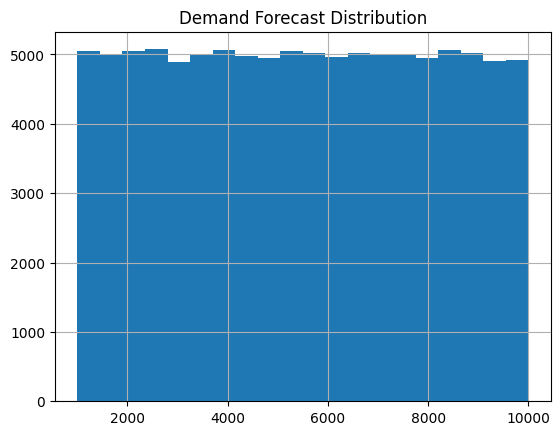

In [4]:
df["Demand_Forecast"].hist(bins=20)
plt.title("Demand Forecast Distribution")
plt.show()

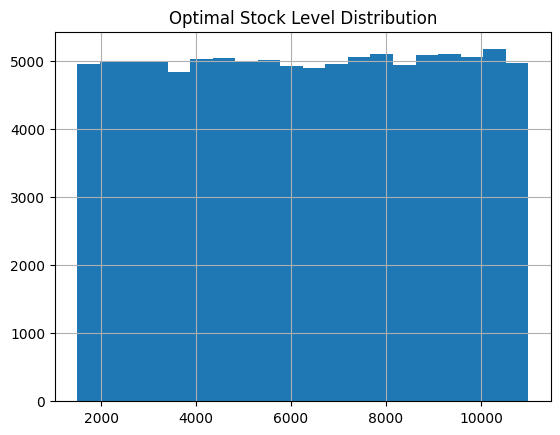

In [5]:
df["Optimal_Stock_Level"].hist(bins=20)
plt.title("Optimal Stock Level Distribution")
plt.show()

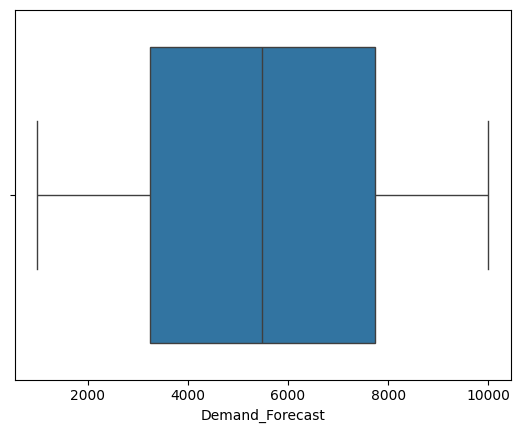

In [6]:
sns.boxplot(x=df["Demand_Forecast"])
plt.show()

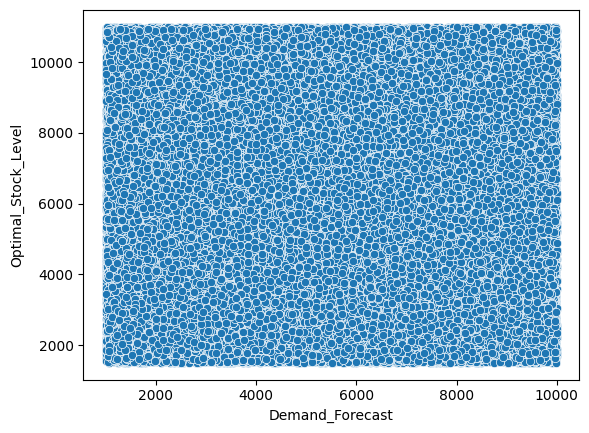

In [7]:
sns.scatterplot(
    x="Demand_Forecast",
    y="Optimal_Stock_Level",
    data=df
)
plt.show()

4. Feature engineering (e.g., dosage to volume ratio,
temperature bands).

In [8]:
import pandas as pd

df = pd.read_excel("Pharmaceutical Supply Chain Optimization.xlsx")

df["Stock_Demand_Ratio"] = (
    df["Optimal_Stock_Level"] / df["Demand_Forecast"]
)
print(df.head())

           Drug  Demand_Forecast  Optimal_Stock_Level Restocking_Strategy  \
0     Metformin             7750                 4753             Monthly   
1    Lisinopril             5136                 9965           Quarterly   
2     Metformin             3183                 2933             Monthly   
3       Insulin             2332                 3927             Monthly   
4  Atorvastatin             3522                 6812             Monthly   

   Stock_Demand_Ratio  
0            0.613290  
1            1.940226  
2            0.921458  
3            1.683962  
4            1.934128  


In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le_drug = LabelEncoder()
le_strategy = LabelEncoder()

df["Drug"] = le_drug.fit_transform(df["Drug"])
df["Restocking_Strategy"] = le_strategy.fit_transform(df["Restocking_Strategy"])

print(df.head())

   Drug  Demand_Forecast  Optimal_Stock_Level  Restocking_Strategy  \
0     3             7750                 4753                    0   
1     2             5136                 9965                    1   
2     3             3183                 2933                    0   
3     1             2332                 3927                    0   
4     0             3522                 6812                    0   

   Stock_Demand_Ratio  
0            0.613290  
1            1.940226  
2            0.921458  
3            1.683962  
4            1.934128  


6. Build a Linear Regression model.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:
df = pd.read_excel("Pharmaceutical Supply Chain Optimization.xlsx")

pd.get_dummies() is used to convert categorical (text) columns into numeric columns because machine learning models like Linear Regression cannot work directly with text values.

In [12]:
df = pd.get_dummies(
    df,
    columns=["Drug", "Restocking_Strategy"],
    drop_first=True
)


In [13]:
X = df.drop("Optimal_Stock_Level", axis=1)
y = df["Optimal_Stock_Level"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()

In [15]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [16]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2373.4663687505886
MSE: 7497938.361235322
RMSE: 2738.236359636495
R2 Score: -9.046078857033457e-05


7. Build and evaluate Random Forest Regressor.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
df = pd.read_excel("Pharmaceutical Supply Chain Optimization.xlsx")

In [19]:
df = pd.get_dummies(
    df,
    columns=["Drug", "Restocking_Strategy"],
    drop_first=True
)

In [20]:
X = df.drop("Optimal_Stock_Level", axis=1)
y = df["Optimal_Stock_Level"]

In [21]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [23]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2638.884885749812
MSE: 10006321.409585288
RMSE: 3163.2770048772663
R2 Score: -0.33466375784688984


8. Compare with Gradient Boosting model.


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
df = pd.read_excel("Pharmaceutical Supply Chain Optimization.xlsx")

In [26]:
df = pd.get_dummies(
    df,
    columns=["Drug", "Restocking_Strategy"],
    drop_first=True
)

In [27]:
X = df.drop("Optimal_Stock_Level", axis=1)
y = df["Optimal_Stock_Level"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


In [30]:
gb = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

In [31]:
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [32]:
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

In [33]:
print("Random Forest")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest
MAE: 2638.884885749812
RMSE: 3163.2770048772663
R2 Score: -0.33466375784688984


In [34]:
print("Gradient Boosting")
print("MAE:", mean_absolute_error(y_test, gb_pred))
print("RMSE:", mean_squared_error(y_test, gb_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, gb_pred))

Gradient Boosting
MAE: 2375.190102961031
RMSE: 2740.7020081367195
R2 Score: -0.0018923371931944821


9. Perform hyperparameter tuning using GridSearchCV.


In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
df = pd.read_excel("Pharmaceutical Supply Chain Optimization.xlsx")

In [37]:
df = pd.get_dummies(
    df,
    columns=["Drug", "Restocking_Strategy"],
    drop_first=True
)

In [38]:
X = df.drop("Optimal_Stock_Level", axis=1)
y = df["Optimal_Stock_Level"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
model = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

In [41]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [42]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2646.419264959005
RMSE: 3172.8938379979327
R2 Score: -0.34279124660612714


10. Evaluate final model with RMSE and crossvalidation.

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

In [44]:
df = pd.read_excel("Pharmaceutical Supply Chain Optimization.xlsx")

In [45]:
df = pd.get_dummies(df,columns=["Drug", "Restocking_Strategy"],drop_first=True)

In [46]:
X = df.drop("Optimal_Stock_Level", axis=1)
y = df["Optimal_Stock_Level"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
model = RandomForestRegressor(n_estimators=100,random_state=42)

In [49]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
y_pred = model.predict(X_test)

In [51]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5

In [53]:
print("RMSE:", rmse)

RMSE: 3163.2770048772663
